In [ ]:
!pip install visualkeras

In [ ]:
!pip install kaggle


In [ ]:
#Upload kaggle.json
from google.colab import files
uploaded = files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

#Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

#Extract zip
import zipfile
with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from google.colab import files
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
train_dir = "/content/chest_xray/train"

rows = []
for label in ["NORMAL", "PNEUMONIA"]:
    folder = os.path.join(train_dir, label)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            rows.append({"filepath": os.path.join(folder, fname), "label": label})

df = pd.DataFrame(rows)

In [ ]:
df_subset = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=1000, random_state=42))
      .reset_index(drop=True)
)
print("Subset distribution:\n", df_subset['label'].value_counts())


Subset distribution:
 label
NORMAL       1000
PNEUMONIA    1000
Name: count, dtype: int64


/tmp/ipykernel_1036/2557216890.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1000, random_state=42))


In [ ]:
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.30,  # 30% sisa untuk val+test
    stratify=df_subset['label'],
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% dari 30% = 15%
    stratify=temp_df['label'],
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train label distribution:\n", train_df['label'].value_counts())
print("Val label distribution:\n", val_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())

Train: 1400 Val: 300 Test: 300
Train label distribution:
 label
NORMAL       700
PNEUMONIA    700
Name: count, dtype: int64
Val label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64
Test label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64


In [ ]:
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32 # dinaikkan agar stabil di GPU dan batch lebih informatif

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generator training
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath',
    y_col='label', target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True, seed=42 )

# ✅ Generator validasi
val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False )

# 🧪 Generator testing
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False )

Found 1400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


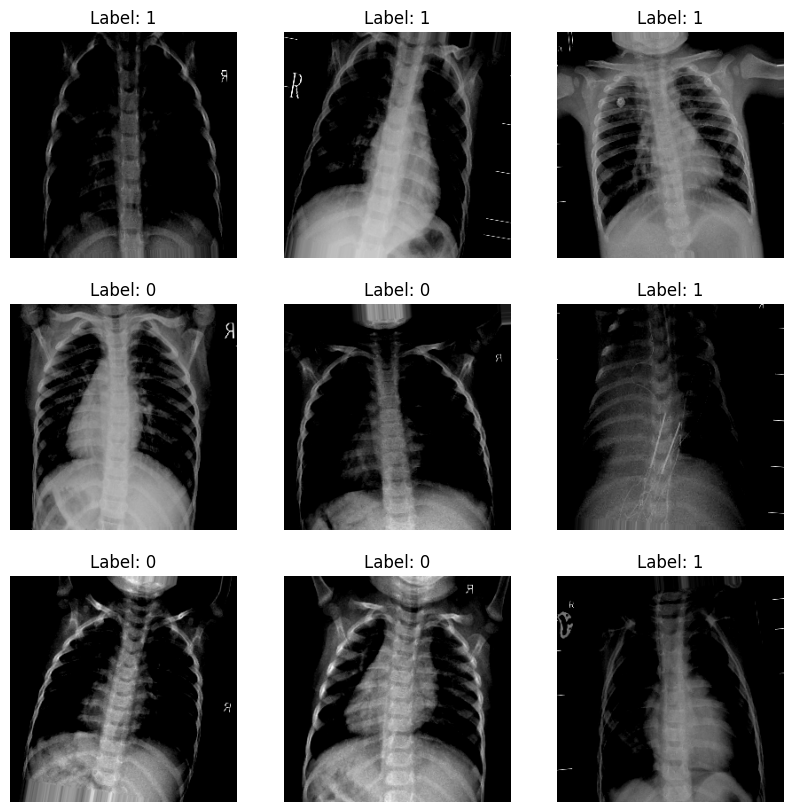

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil satu batch data dari generator
images, labels = next(train_gen)

# Tampilkan 9 contoh gambar
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")
plt.show()


In [ ]:
labels = train_df['label'].map({'NORMAL':0, 'PNEUMONIA':1}).values
classes = np.unique(labels)
class_weights = compute_class_weight('balanced', classes=classes, y=labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Freeze base model (penting untuk awal training)
base_model.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

model.summary()

/tmp/ipykernel_1036/4150718641.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6824 - loss: 0.5966 - val_accuracy: 0.9400 - val_loss: 0.2811
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 869ms/step - accuracy: 0.8885 - loss: 0.3052 - val_accuracy: 0.9467 - val_loss: 0.1997
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 922ms/step - accuracy: 0.9198 - loss: 0.2324 - val_accuracy: 0.9500 - val_loss: 0.1641
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 862ms/step - accuracy: 0.9239 - loss: 0.1970 - val_accuracy: 0.9567 - val_loss: 0.1418
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 859ms/step - accuracy: 0.9303 - loss: 0.1784 - val_accuracy: 0.9567 - val_loss: 0.1317
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 858ms/step - accuracy: 0.9468 - loss: 0.1524 - val_accuracy: 0.9567 - val_loss: 0.1225
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 863ms/step - accuracy: 0.9435 - loss: 0.1488 - val_accuracy: 0.9567 - val_loss: 0.1246
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 862ms/step - accuracy: 0.9563 - loss: 0.1380 - val_accurac

In [ ]:
base_model.trainable = True

# Freeze sebagian besar layer, buka 30 layer terakhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='auc')
    ]
)

In [ ]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9036 - auc: 0.9741 - loss: 0.2306 - val_accuracy: 0.9533 - val_auc: 0.9956 - val_loss: 0.1156
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 875ms/step - accuracy: 0.9262 - auc: 0.9777 - loss: 0.1938 - val_accuracy: 0.9567 - val_auc: 0.9959 - val_loss: 0.1172
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 873ms/step - accuracy: 0.9594 - auc: 0.9896 - loss: 0.1284 - val_accuracy: 0.9533 - val_auc: 0.9958 - val_loss: 0.1090
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 867ms/step - accuracy: 0.9534 - auc: 0.9909 - loss: 0.1233 - val_accuracy: 0.9700 - val_auc: 0.9962 - val_loss: 0.1019
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 868ms/step - accuracy: 0.9593 - auc: 0.9927 - loss: 0.1148 - val_accuracy: 0.9733 - val_auc: 0.9962 - val_loss: 0.0953
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 871ms/step - accuracy: 0.9735 - auc: 0.9940 - loss: 0.0944 - val_accuracy: 0.9700 - val_auc: 0.9962 - val_loss: 0.0894
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━

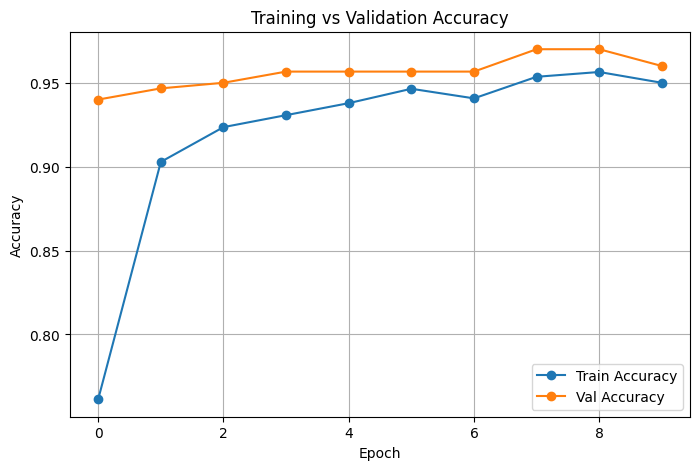

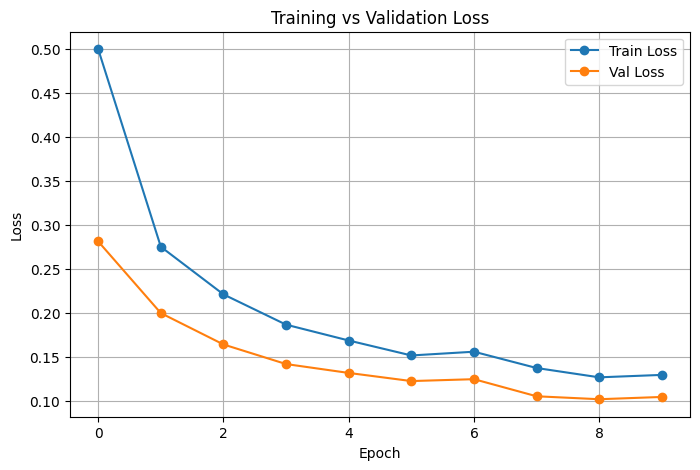

KeyError: 'auc'

<Figure size 800x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# --- Akurasi ---
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- AUC ---
plt.figure(figsize=(8,5))
plt.plot(history.history['auc'], label='Train AUC', marker='o')
plt.plot(history.history['val_auc'], label='Val AUC', marker='o')
plt.title('Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
test_loss, test_auc, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

y_true = test_gen.classes
y_pred = model.predict(test_gen).ravel()
y_pred_classes = (y_pred > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
print(classification_report(y_true, y_pred_classes, target_names=["NORMAL","PNEUMONIA"]))
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 602ms/step - accuracy: 0.9780 - auc: 0.9978 - loss: 0.0682
Test Accuracy: 0.9979 | Test AUC: 0.9800
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       150
   PNEUMONIA       0.98      0.98      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

Confusion Matrix:
 [[147   3]
 [  3 147]]


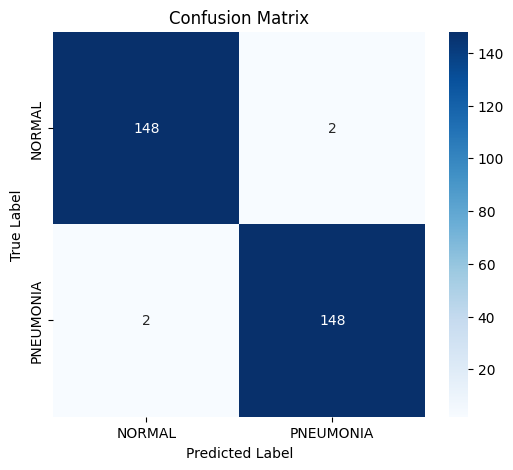

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Misal cm sudah ada (confusion matrix numpy array)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
